# Example: Single Index Model Inputs and Minimum-Variance Portfolios

In the L6a data example, we chose minimum-variance portfolios from a sample-mean growth-rate vector and a sample covariance matrix. In the lecture, we built both inputs from a single index model (SIM), which needs far fewer parameters. Does the covariance model change the portfolio we choose?

> __Learning Objectives:__
>
> By the end of this example, you should be able to:
>
> * __Assemble the SIM inputs for a portfolio:__ Combine the archived intercepts, betas, and residual variances with the training-period market mean and variance into the SIM mean vector and covariance matrix. Verify that the SIM mean vector reproduces the sample means exactly.
> * __Locate the SIM covariance error:__ Show that off the diagonal, the SIM covariance is the sample covariance with the residual covariances set to zero. Identify the pairs of firms whose co-movement the SIM misses.
> * __Compare the frontiers and the portfolios:__ Trace the long-only efficient frontier from each input set, and evaluate the SIM-selected weights under the sample covariance. Compare the weights at a target growth rate, and score the portfolios out of sample on 2025 data.

In this example, we build both input sets for the same firms from 2014 to 2024 data and compare the portfolios they select. We reserve 2025 prices for the final comparison, so they do not influence either allocation.

Let's get started!

___

## Setup, Data, and Prerequisites
First, we load the local [`Include.jl`](Include.jl) setup file and its required packages.

> __Include:__ The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates [`Include.jl`](Include.jl) in the notebook's global scope. The setup file activates the course project, defines local paths, and loads the required packages.

Let's set up our code environment:

In [1]:
# Load the course environment, market data, and portfolio solver -
include(joinpath(@__DIR__, "Include.jl")); # resolve setup relative to this notebook

See the [Julia documentation](https://docs.julialang.org/en/v1/) and the [CHEME 5660 Quantitative Finance Package documentation](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/) for the functions and types used here.

### Data
We use the daily volume-weighted average price (VWAP) of firms in the [S&P 500](https://en.wikipedia.org/wiki/S%26P_500), with 2014 to 2024 for training and 2025 for testing. Let's load the training data using [the `MyTrainingMarketDataSet()` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/data/#VLQuantitativeFinancePackage.MyTrainingMarketDataSet), keep the tickers with as many price records as `AAPL`, and store them in `dataset::Dict{String,DataFrame}`:

In [2]:
dataset = let # variables created inside a let block stay local to it

    # Load the training prices, 2014 to 2024 -
    # |> pipes the loaded Dict into x -> x["dataset"], which returns the ticker-keyed price tables.
    original_dataset = MyTrainingMarketDataSet() |> x-> x["dataset"];
    maximum_number_trading_days = original_dataset["AAPL"] |> nrow; # AAPL has a full history
    dataset = Dict{String, DataFrame}(); # empty dictionary, filled below with complete histories

    # Keep only the tickers with as many price rows as AAPL -
    # Task 1 checks that the selected firms also share the same dates.
    for (ticker, data) ∈ original_dataset # each entry unpacks into (key, value), in no fixed order
        if (nrow(data) == maximum_number_trading_days)
            dataset[ticker] = data;
        end
    end
    dataset; # a let block returns its last expression, which becomes the global dataset
end;

Next, we load the 2025 testing data the same way using [the `MyTestingMarketDataSet()` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/data/#VLQuantitativeFinancePackage.MyTestingMarketDataSet) and store it in `dataset_2025::Dict{String,DataFrame}`:

In [3]:
dataset_2025 = let

    # Load the testing prices, calendar year 2025 -
    original_dataset = MyTestingMarketDataSet() |> x-> x["dataset"]; # default year is 2025
    maximum_number_trading_days = original_dataset["AAPL"] |> nrow; # AAPL's 2025 trading days
    dataset = Dict{String, DataFrame}(); # complete 2025 histories, keyed by ticker

    # Keep only the tickers with as many price rows as AAPL, as for the training data -
    for (ticker, data) ∈ original_dataset
        if (nrow(data) == maximum_number_trading_days)
            dataset[ticker] = data;
        end
    end
    dataset; # return the filtered testing data
end;

We also load the [SIM parameter archive](data/SIMs-SP500-01-03-14-to-12-31-24.jld2) saved by the L6b estimation example, using [the `JLD2.load(...)` function](https://juliaio.github.io/JLD2.jl/stable/basic_usage/#FileIO-interface). For each security, it holds the fitted $\hat{\alpha}_{i}$, $\hat{\beta}_{i}$, and residual variance $s^{2}_{g,\varepsilon,i}$. It also holds the training-period market mean $g^{\prime}_{M}$ and variance $s^{2}_{g,M}$. After checking the archive's conventions, we store these in `sim_parameters::Dict{String,NamedTuple}`, `g_market_mean::Float64`, and `σ²_market::Float64`:

In [4]:
sim_parameters, g_market_mean, σ²_market = let

    # Load the SIM parameter archive saved by the L6b estimation example -
    archive = JLD2.load(joinpath(_PATH_TO_DATA, "SIMs-SP500-01-03-14-to-12-31-24.jld2")); # Dict keyed by field name

    # Check that the archive uses the conventions of this example -
    @assert archive["schema_version"] == 2 # the archive layout this notebook reads
    @assert archive["market_ticker"] == "SPY" # the market growth rate g_M comes from SPY
    @assert isapprox(archive["delta_t"], 1/252) # daily growth rates, Δt = 1/252 yr
    @assert archive["variance_convention"] == "growth_rate" # residual variances are Var(ε) in 1/yr², as in the lecture

    # Report what we loaded. [1:10] keeps the yyyy-mm-dd part of each date string -
    println("SIM archive: $(length(archive["data"])) securities fitted against $(archive["market_ticker"]) on $(archive["date_range"][1][1:10]) to $(archive["date_range"][2][1:10])")
    (archive["data"], archive["market_mean"], archive["market_variance"]); # unpacks, in order, into the three names on the first line
end;

SIM archive: 424 securities fitted against SPY on 2014-01-03 to 2024-12-31


### Constants
Finally, we set the daily time step, initial wealth, and number of target growth rates in the frontier sweep. The comments below give their meaning and units.

In [5]:
# Set the common time/wealth units and the resolution of the numerical target sweep -
Δt = (1.0/252.0); # time step (1 trading day, in years)
W₀ = 1000.0; # initial wealth (units: USD)
number_of_points = 101; # number of target growth rates in each frontier sweep

___

## Task 1: Estimate and Compare the Portfolio Inputs
In this task, we build both input sets for the same firms and find the pairs of firms whose co-movement the SIM misses.

### Choose the firms
We start with the thirteen firms of the L6a data example. If the L6b client interview files have been copied into this notebook's `data` folder, we use the list in `data/my-tickers.csv` instead. You can change the list, but fix it before looking at 2025 performance. Specify the ticker symbols in `my_list_of_tickers::Array{String,1}`:

In [6]:
# Fix the asset universe before looking at 2025 performance -
# This order sets the order of every mean, covariance row and column, weight, and price column.
my_list_of_tickers = ["AAPL", "MSFT", "INTC", "MU", "AMD", "NVDA", "GS", "BAC", "WFC", "C", "F", "GM", "JNJ"]; # the 13 L6a firms

# Use the client interview's list instead, if the interview has written one -
path_to_client_tickers = joinpath(_PATH_TO_DATA, "my-tickers.csv"); # copied from the L6b client interview
if (isfile(path_to_client_tickers))
    my_list_of_tickers = String.(CSV.read(path_to_client_tickers, DataFrame).ticker); # String.(...) converts CSV's compact strings
end
println("|𝒫| = $(length(my_list_of_tickers)) firms: $(join(my_list_of_tickers, ", "))")

|𝒫| = 13 firms: AAPL, MSFT, INTC, MU, AMD, NVDA, GS, BAC, WFC, C, F, GM, JNJ


### Build both input sets
As in the L6a data example, we build the growth-rate matrix $\mathbf{G}$ [using the `log_growth_matrix(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/equity/#VLQuantitativeFinancePackage.log_growth_matrix). From it, we compute the sample-mean vector $\mathbf{g}^{\prime}$ and the sample covariance $\hat{\mathbf{\Sigma}}_{g}$. We also keep the SPY growth rate $g_{M,t}$ to check the archive's market moments.

We store the results in `ĝ`, `Σ̂_g`, and `g_market`:

In [7]:
ĝ, Σ̂_g, g_market = let

    # Check that the selected firms and SPY share the same trading dates and have positive prices -
    # log_growth_matrix pairs prices by row position. @assert stops the cell if a check is false.
    # >(0) is the function x -> x > 0, so all(>(0), prices) checks that every price is positive.
    for ticker ∈ vcat(my_list_of_tickers, "SPY") # vcat appends SPY to the ticker list
        @assert dataset[ticker].timestamp == dataset["AAPL"].timestamp
        @assert dataset_2025[ticker].timestamp == dataset_2025["AAPL"].timestamp
        @assert all(isfinite, dataset[ticker].volume_weighted_average_price) && all(>(0), dataset[ticker].volume_weighted_average_price)
        @assert all(isfinite, dataset_2025[ticker].volume_weighted_average_price) && all(>(0), dataset_2025[ticker].volume_weighted_average_price)
    end

    # Build the growth-rate matrix G (N days × |𝒫| firms) and the market series -
    G = log_growth_matrix(dataset, my_list_of_tickers, Δt = Δt); # g in row k, column i (1/yr)
    g_market = log_growth_matrix(dataset, ["SPY"], Δt = Δt) |> vec; # SPY growth rates g_M,t (1/yr), vec turns N × 1 into a vector

    # Estimate the data-driven inputs -
    # dims=1 works down each column (over days). vec turns the 1 × |𝒫| mean into a vector.
    ĝ = mean(G, dims=1) |> vec; # sample-mean growth vector g′ (1/yr)
    Σ̂_g = cov(G, dims=1); # |𝒫| × |𝒫| sample covariance Σ̂_g with the N-1 divisor (1/yr²)
    @assert isposdef(Σ̂_g) # positive definite, so each feasible problem has a unique solution

    (ĝ, Σ̂_g, g_market); # unpacks, in order, into the three names on the first line
end;
println("N = $(length(g_market)) training days, |𝒫| = $(length(my_list_of_tickers)) firms")

N = 2766 training days, |𝒫| = 13 firms


Next, we assemble the SIM inputs from the archived parameters and the two market moments, as in the lecture:

$$
\hat{\mathbf{g}}_{\text{SIM}} = \hat{\boldsymbol{\alpha}} + \hat{\boldsymbol{\beta}}\,g^{\prime}_{M},\qquad
\hat{\mathbf{\Sigma}}_{g,\text{SIM}} = s^{2}_{g,M}\,\hat{\boldsymbol{\beta}}\hat{\boldsymbol{\beta}}^{\top} + \hat{\mathbf{D}}_{g}
$$

where $\hat{\mathbf{D}}_{g}$ is the diagonal matrix of residual variances $s^{2}_{g,\varepsilon,i}$. The market moments must come from the training days used to fit $\hat{\alpha}_{i}$ and $\hat{\beta}_{i}$, so we first check them against the SPY series.

We store the inputs in `ĝ_sim` and `Σ̂_g_sim`, and keep `α̂` and `β̂` for later:

In [8]:
ĝ_sim, Σ̂_g_sim, α̂, β̂ = let

    # Check that the archive's market moments are the training-period sample moments of SPY -
    @assert isapprox(g_market_mean, mean(g_market), rtol = 1e-10) # g′_M (1/yr)
    @assert isapprox(σ²_market, var(g_market), rtol = 1e-10) # s²_g,M (1/yr²)

    # Look up the SIM parameters for our firms, in ticker order -
    α̂ = [sim_parameters[ticker].alpha for ticker ∈ my_list_of_tickers]; # intercepts α̂ᵢ (1/yr)
    β̂ = [sim_parameters[ticker].beta for ticker ∈ my_list_of_tickers]; # betas β̂ᵢ (dimensionless)
    s²_ε = [sim_parameters[ticker].training_variance for ticker ∈ my_list_of_tickers]; # residual variances s²_g,ε,i (1/yr²)

    # Assemble the SIM inputs -
    ĝ_sim = α̂ .+ β̂ .* g_market_mean; # SIM mean vector (1/yr)
    Σ̂_g_sim = σ²_market .* (β̂ * β̂') .+ Diagonal(s²_ε); # β̂ * β̂' is the |𝒫| × |𝒫| outer product, σ²_market carries the units (1/yr²)
    @assert isposdef(Σ̂_g_sim) # positive residual variances make the SIM covariance positive definite

    (ĝ_sim, Matrix(Σ̂_g_sim), α̂, β̂); # Matrix(...) stores a plain dense matrix
end;

### How are the two input sets related?
The lecture showed two facts about these inputs when both come from the same training days:

* __The means agree:__ A least-squares line with an intercept passes through the sample means, so $\hat{\mathbf{g}}_{\text{SIM}}=\mathbf{g}^{\prime}$.
* __The covariances differ by the residual covariances:__ Off the diagonal, the sample covariance splits into two terms:

$$
\hat{\Sigma}_{g,ij}=\underbrace{\hat{\beta}_{i}\hat{\beta}_{j}\,s^{2}_{g,M}}_{\text{SIM keeps}}+\underbrace{\widehat{\text{Cov}}(\mathbf{r}_{i},\mathbf{r}_{j})}_{\text{SIM drops}}\qquad(i\neq j)
$$

where $\mathbf{r}_{i}$ is firm $i$'s residual series. On the diagonal, the two covariances differ only by the factor $(N-1)/(N-2)$ on the residual variance. Let's check the first fact:

In [9]:
let
    # Compare the SIM mean vector with the sample means -
    println("max |ĝ_sim - ĝ| = $(maximum(abs.(ĝ_sim .- ĝ))) 1/yr")
    @assert isapprox(ĝ_sim, ĝ, rtol = 1e-10, atol = 1e-10) # equal in exact arithmetic, so only roundoff remains
end

max |ĝ_sim - ĝ| = 1.1102230246251565e-15 1/yr


For the second, we rebuild each firm's residual series from $\mathbf{G}$, $\hat{\alpha}_{i}$, $\hat{\beta}_{i}$, and the market series, and store their covariance matrix in `Ω̂_ε::Array{Float64,2}`:

In [10]:
Ω̂_ε = let
    N = length(g_market); # number of training days
    M = length(my_list_of_tickers); # number of firms |𝒫|

    # Rebuild the fitted residual series, one column per firm -
    G = log_growth_matrix(dataset, my_list_of_tickers, Δt = Δt); # the same G as above (1/yr)
    R = G .- (ones(N)*α̂' .+ g_market*β̂'); # column i holds rᵢ = yᵢ - α̂ᵢ - β̂ᵢ g_M (1/yr)
    Ω̂_ε = cov(R, dims=1); # residual covariance matrix (1/yr²)

    # Check the off-diagonal split: Σ̂_g - Σ̂_g_sim equals Ω̂_ε for every pair i ≠ j -
    difference = Σ̂_g .- Σ̂_g_sim; # sample minus SIM covariance, equal to Ω̂_ε off the diagonal (1/yr²)
    off_diagonal_error = maximum(abs(difference[i,j] - Ω̂_ε[i,j]) for i ∈ 1:M, j ∈ 1:M if i != j);
    println("max off-diagonal |Σ̂_g - Σ̂_g_sim - Ω̂_ε| = $(off_diagonal_error) 1/yr²")
    @assert off_diagonal_error < 1e-10 # equal in exact arithmetic

    # Check the diagonal: each ratio lies between 1 and (N-1)/(N-2) -
    ratio = diag(Σ̂_g_sim) ./ diag(Σ̂_g); # SIM variance over sample variance, one per firm
    println("diagonal ratio Σ̂_g_sim / Σ̂_g from $(round(minimum(ratio), digits=5)) to $(round(maximum(ratio), digits=5)), (N-1)/(N-2) = $(round((N-1)/(N-2), digits=5))")
    @assert all(1 - 1e-12 .≤ ratio .≤ (N-1)/(N-2) + 1e-12)

    Ω̂_ε; # return
end;

max off-diagonal |Σ̂_g - Σ̂_g_sim - Ω̂_ε| = 1.3322676295501878e-14 1/yr²


diagonal ratio Σ̂_g_sim / Σ̂_g from 1.00017 to 1.00028, (N-1)/(N-2) = 1.00036


### Which pairs does the SIM miss?
Let's compare the two correlation matrices on the same color scale (blue positive, red negative, white zero) [using the `heatmap(...)` function](https://docs.juliaplots.org/stable/api/#Plots.heatmap-Tuple). The sample correlation is on the left, and the SIM-implied correlation is on the right. `Unhide` the code block below to see how we made the plot:

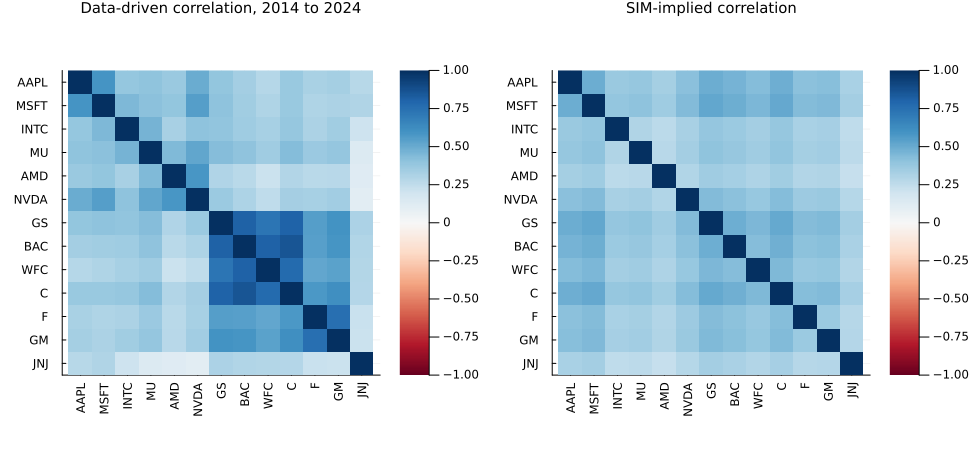

In [11]:
let
    # Convert both covariance matrices to correlations, ρᵢⱼ = Σᵢⱼ/(σᵢσⱼ) -
    M = length(my_list_of_tickers); # number of firms
    σ = sqrt.(diag(Σ̂_g)); # sample growth-rate standard deviations (1/yr)
    σ_sim = sqrt.(diag(Σ̂_g_sim)); # SIM growth-rate standard deviations (1/yr)
    ρ̂ = Σ̂_g ./ (σ*σ'); # σ*σ' is the M × M outer product σᵢσⱼ, ./ divides entrywise
    ρ̂_sim = Σ̂_g_sim ./ (σ_sim*σ_sim');

    # Plot the two matrices side by side on the same color scale -
    # clims fixes the scale to [-1, 1]. yflip puts matrix row 1 at the top.
    p1 = heatmap(ρ̂, xticks = (1:M, my_list_of_tickers), yticks = (1:M, my_list_of_tickers), xrotation = 90,
        color = :RdBu, clims = (-1, 1), colorbar_ticks = (-1:0.5:1), aspect_ratio = :equal, yflip = true,
        title = "Data-driven correlation, 2014 to 2024", titlefontsize = 10);
    p2 = heatmap(ρ̂_sim, xticks = (1:M, my_list_of_tickers), yticks = (1:M, my_list_of_tickers), xrotation = 90,
        color = :RdBu, clims = (-1, 1), colorbar_ticks = (-1:0.5:1), aspect_ratio = :equal, yflip = true,
        title = "SIM-implied correlation", titlefontsize = 10);
    plot(p1, p2, layout = (1, 2), size = (980, 470), left_margin = 2Plots.mm, bottom_margin = 4Plots.mm)
end

__What do we see?__

* __SIM pattern:__ Each off-diagonal SIM correlation is $\hat{\beta}_{i}\hat{\beta}_{j}s^{2}_{g,M}$ divided by the two standard deviations. It is set by each firm's own beta and variance, and the SIM has no term that directly links two particular firms.
* __Sample pattern:__ Look for groups of firms, often in the same industry, that are more correlated in the sample than in the SIM. They move together more than their betas explain.

Let's measure the gap with the residual correlation matrix and list the pairs with the largest positive and negative residual correlations:

In [12]:
let
    # Convert the three covariance matrices to correlations -
    M = length(my_list_of_tickers); # number of firms
    σ_ε = sqrt.(diag(Ω̂_ε)); # residual standard deviations (1/yr)
    ρ̂_ε = Ω̂_ε ./ (σ_ε*σ_ε'); # residual correlation matrix
    σ = sqrt.(diag(Σ̂_g));
    ρ̂ = Σ̂_g ./ (σ*σ'); # sample correlation
    σ_sim = sqrt.(diag(Σ̂_g_sim));
    ρ̂_sim = Σ̂_g_sim ./ (σ_sim*σ_sim'); # SIM-implied correlation

    # List each pair (i, j) with i < j once, sorted by residual correlation -
    pairs = [(i, j) for i ∈ 1:M for j ∈ (i+1):M]; # M(M-1)/2 pairs
    sort!(pairs, by = p -> ρ̂_ε[p[1], p[2]]); # most negative first

    # Tabulate the five most positive and the five most negative pairs -
    n_show = min(5, length(pairs)); # fewer when the list has fewer than five pairs
    df = DataFrame(pair = String[], residual_corr = Float64[], data_corr = Float64[], SIM_corr = Float64[]);
    for (i, j) ∈ unique(vcat(reverse(pairs[end-n_show+1:end]), pairs[1:n_show])) # unique drops repeats when the lists overlap
        push!(df, (pair = "$(my_list_of_tickers[i])-$(my_list_of_tickers[j])", residual_corr = round(ρ̂_ε[i,j], digits=3),
            data_corr = round(ρ̂[i,j], digits=3), SIM_corr = round(ρ̂_sim[i,j], digits=3)));
    end
    pretty_table(df, backend = :text, table_format = TextTableFormat(borders = text_table_borders__compact))

    # Summarize all pairs with the median absolute residual correlation -
    all_residual_corr = [abs(ρ̂_ε[i,j]) for (i, j) ∈ pairs];
    println("median |residual correlation| over the $(length(pairs)) pairs: $(round(median(all_residual_corr), digits=3))")
end

 ---------- --------------- ----------- ----------
      pair   residual_corr   data_corr   SIM_corr 
    String         Float64     Float64    Float64 
 ---------- --------------- ----------- ----------
     BAC-C           0.736       0.864      0.487
   BAC-WFC           0.677       0.815      0.431
    GS-BAC           0.637       0.815      0.493
      F-GM           0.617        0.76      0.372
      GS-C           0.611       0.811      0.513
    MSFT-C          -0.284       0.377      0.515
  MSFT-BAC          -0.279       0.353      0.494
  MSFT-WFC          -0.274       0.309      0.456
  AAPL-WFC           -0.26       0.288      0.434
  NVDA-JNJ          -0.252       0.112      0.288
 ---------- --------------- ----------- ----------
median |residual correlation| over the 78 pairs: 0.142

__What do we see?__

* __Sign:__ A positive residual correlation means two firms move together more than their market exposure explains, so the SIM understates their covariance. A negative one means the SIM overstates it.
* __Size:__ The table shows the extremes, and the median summarizes all pairs. A small median means at least half the pairs have small residual correlations, even when the extremes are large.

Next, we see what these errors do to the portfolios.

___

## Task 2: Construct the Frontiers and Compare Allocations
In this task, we trace the long-only frontier from each input set and compare the risk and weights of the portfolios they select.

### Build and solve both problems
We solve the lecture's long-only problem (SIM-1) with each input set. As in the L6a data example, we build each problem as an instance of [the `MyMarkowitzRiskyAssetOnlyPortfolioChoiceProblem` type](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/portfolio/#VLQuantitativeFinancePackage.MyMarkowitzRiskyAssetOnlyPortfolioChoiceProblem) [using the `build(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/portfolio/#VLQuantitativeFinancePackage.build-Tuple{Type{MyMarkowitzRiskyAssetOnlyPortfolioChoiceProblem},%20NamedTuple}). The initial growth floor, the smallest mean growth rate, excludes no long-only portfolio, so the first solve gives the long-only global minimum-variance (GMV) portfolio.

Let's build the two problems and store them in `problem_data` and `problem_sim`:

In [13]:
problem_data, problem_sim = let
    M = length(my_list_of_tickers); # number of firms

    # Set the long-only bounds 0 ≤ wᵢ ≤ 1 -
    # solve(...) adds the budget 1ᵀw = 1, so these bounds give a fully invested long-only portfolio.
    bounds = zeros(M, 2); # one row per firm, column 1 holds the lower bounds (zero)
    bounds[:,2] .= 1.0; # .= fills column 2, the upper bounds, with ones in place

    # Build the problem with the sample inputs -
    problem_data = build(MyMarkowitzRiskyAssetOnlyPortfolioChoiceProblem, (
        Σ = Σ̂_g, # sample covariance Σ̂_g (1/yr²)
        μ = ĝ, # field μ receives the sample-mean growth vector g′ (1/yr)
        bounds = bounds, # 0 ≤ wᵢ ≤ 1
        initial = (1/M)*ones(M), # solver starting point: equal weights
        R = minimum(ĝ) # growth floor g⋆ = minᵢ g′ᵢ, which every long-only portfolio meets
    ));

    # Build the same problem with the SIM inputs -
    problem_sim = build(MyMarkowitzRiskyAssetOnlyPortfolioChoiceProblem, (
        Σ = Σ̂_g_sim, # SIM covariance Σ̂_g,SIM (1/yr²)
        μ = ĝ_sim, # SIM mean vector, equal to g′ (1/yr)
        bounds = bounds,
        initial = (1/M)*ones(M),
        R = minimum(ĝ_sim)
    ));
    (problem_data, problem_sim); # unpacks, in order, into the two names on the first line
end;

Now call [the `solve(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/portfolio/#VLQuantitativeFinancePackage.solve-Tuple{MyMarkowitzRiskyAssetOnlyPortfolioChoiceProblem}) for each problem. We check the solver status and store the GMV weights in `w_GMV_data` and `w_GMV_sim`:

In [14]:
w_GMV_data, w_GMV_sim = let
    # Reset each growth floor to the smallest mean growth rate, which excludes no portfolio (the sweep changes it) -
    problem_data.R = minimum(ĝ);
    problem_sim.R = minimum(ĝ_sim);

    # Solve both long-only GMV problems and check the solver status -
    solution_data = solve(problem_data); # Dict of results. solve raises an AssertionError if MadNLP fails
    solution_sim = solve(problem_sim);
    # LOCALLY_SOLVED is MadNLP's success status. The problem is convex, so this minimum is global.
    @assert solution_data["status"] == MathOptInterface.LOCALLY_SOLVED
    @assert solution_sim["status"] == MathOptInterface.LOCALLY_SOLVED
    (solution_data["argmax"], solution_sim["argmax"]); # the legacy key "argmax" holds the minimizing weights
end;

### Sweep a common set of growth floors
To compare the input sets at the same growth requirement, we solve both problems at the same floors $g_{\star}$. The floors run from the higher of the two GMV growth rates to just below $\max_i g_i^{\prime}$, so the floor binds for both problems.

Each row of `frontier_data` and `frontier_sim` holds one floor, the achieved mean growth, the risk, and the weights. A failed solve leaves `NaN`, so row $k$ refers to the same floor in both tables:

In [15]:
frontier_data, frontier_sim = let
    M = length(my_list_of_tickers); # number of firms

    # Set the common growth floors g⋆ -
    # Below the higher GMV growth rate, one of the problems would return its GMV portfolio.
    g_low = max(ĝ'*w_GMV_data, ĝ'*w_GMV_sim); # higher of the two GMV growth rates (1/yr)
    g_high = max(g_low, maximum(ĝ) - 1e-4); # just below maxᵢ g′ᵢ, which no long-only portfolio can exceed (1/yr)
    targets = range(g_low, stop = g_high, length = number_of_points) |> collect;

    # Solve each problem at every floor -
    frontiers = Dict{String, DataFrame}(); # one results table per input set
    for (name, problem) ∈ [("data", problem_data), ("SIM", problem_sim)]
        df = DataFrame(g_target = Float64[], g = Float64[], σ = Float64[], σ_sample = Float64[], w = Vector{Float64}[]);
        for target ∈ targets
            problem.R = target; # change only the growth floor g⋆ in the mutable problem
            w = fill(NaN, M); # stays NaN if the solve fails
            try # solve(...) raises an AssertionError if the solver fails
                solution = solve(problem);
                if (solution["status"] == MathOptInterface.LOCALLY_SOLVED)
                    w = solution["argmax"]; # minimizing weights for this floor, in ticker order
                end
            catch err # a failed solve keeps w = NaN, but rethrow any other kind of error
                err isa AssertionError || rethrow() # || runs rethrow() only when the left side is false
            end
            # problem.Σ is the problem's own covariance. σ_sample scores the same weights under Σ̂_g.
            # ĝ_sim = ĝ (Task 1), so one mean vector gives the achieved growth for both problems.
            push!(df, (g_target = target, g = ĝ'*w, σ = sqrt(w'*problem.Σ*w), σ_sample = sqrt(w'*Σ̂_g*w), w = w));
        end
        frontiers[name] = df;
        println("$(name) inputs: solved $(count(!isnan, df.σ)) of $(number_of_points) floors") # !isnan is the function x -> !isnan(x)
    end
    (frontiers["data"], frontiers["SIM"]); # unpacks into frontier_data and frontier_sim
end;

data inputs: solved 101 of 101 floors


SIM inputs: solved 101 of 101 floors


### Compare the risk
At each floor, we now have three growth-rate standard deviations:

* __Data frontier:__ The sample-input weights under the sample covariance, `frontier_data.σ`.
* __SIM frontier (SIM-believed risk):__ The SIM weights under the SIM covariance, `frontier_sim.σ`.
* __SIM weights under the sample covariance:__ `frontier_sim.σ_sample`.

Let's plot the frontiers (left) and the percent gaps to the data frontier (right) [using the `plot(...)` function](https://docs.juliaplots.org/stable/api/#Plots.plot-Tuple). `Unhide` the code block below to see how we made the plot:

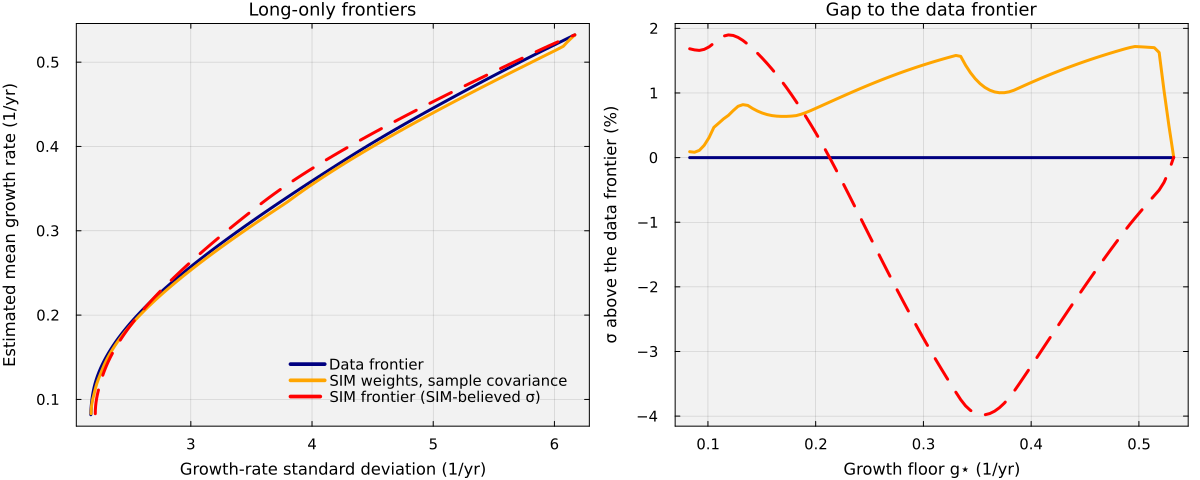

In [16]:
let
    # Left panel: each frontier starts at its GMV portfolio -
    g_GMV_data = ĝ'*w_GMV_data; # data GMV growth rate (1/yr)
    g_GMV_sim = ĝ'*w_GMV_sim; # SIM GMV growth rate (1/yr)
    σ_GMV_data = sqrt(w_GMV_data'*Σ̂_g*w_GMV_data); # data GMV risk under Σ̂_g (1/yr)
    σ_GMV_sim = sqrt(w_GMV_sim'*Σ̂_g_sim*w_GMV_sim); # SIM GMV risk under Σ̂_g,SIM (1/yr)
    σ_GMV_sim_sample = sqrt(w_GMV_sim'*Σ̂_g*w_GMV_sim); # SIM GMV risk under Σ̂_g (1/yr)
    p1 = plot(vcat(σ_GMV_data, frontier_data.σ), vcat(g_GMV_data, frontier_data.g), lw = 3, c = :navy, label = "Data frontier")
    plot!(p1, vcat(σ_GMV_sim_sample, frontier_sim.σ_sample), vcat(g_GMV_sim, frontier_sim.g), lw = 3, c = :orange,
        label = "SIM weights, sample covariance")
    plot!(p1, vcat(σ_GMV_sim, frontier_sim.σ), vcat(g_GMV_sim, frontier_sim.g), lw = 3, ls = :dash, c = :red,
        label = "SIM frontier (SIM-believed σ)")
    plot!(p1, xlabel = "Growth-rate standard deviation (1/yr)", ylabel = "Estimated mean growth rate (1/yr)",
        title = "Long-only frontiers", legend = :bottomright, background_color_legend = nothing) # see-through legend box

    # Right panel: each σ as a percent gap to the data frontier at the same floor g⋆ -
    gap(σ) = 100 .* (σ .- frontier_data.σ) ./ frontier_data.σ; # percent above the data frontier, so the data frontier sits at zero
    p2 = plot(frontier_data.g_target, gap(frontier_data.σ), lw = 3, c = :navy, label = false)
    plot!(p2, frontier_sim.g_target, gap(frontier_sim.σ_sample), lw = 3, c = :orange, label = false)
    plot!(p2, frontier_sim.g_target, gap(frontier_sim.σ), lw = 3, ls = :dash, c = :red, label = false)
    plot!(p2, xlabel = "Growth floor g⋆ (1/yr)", ylabel = "σ above the data frontier (%)", title = "Gap to the data frontier")

    # Put the panels side by side and style both -
    plot(p1, p2, layout = (1, 2), size = (1200, 480), titlefontsize = 12, guidefontsize = 11, tickfontsize = 10,
        legendfontsize = 10, bg = "gray95", background_color_outside = "white", framestyle = :box,
        fg_legend = :transparent, left_margin = 5Plots.mm, bottom_margin = 5Plots.mm)
end

__What do we see?__

* __Frontiers:__ The two input sets share the mean vector, so the gap between the frontiers comes mainly from the residual covariances the SIM drops.
* __SIM belief (red):__ Red above orange means the SIM overstates its own portfolio's risk, and red below means it understates it. Positive residual correlations among the firms the portfolio holds pull red below orange, and negative ones push it above.
* __Extra risk (orange):__ This line stays at or above zero because the data frontier minimizes the sample-covariance risk at each floor. Its height is the cost of the SIM's simpler covariance.

### Compare the weights
Do the two input sets pick different portfolios? We compare the weights at the two GMV portfolios and at the middle floor of the sweep, `g_target`. The table puts each firm's beta next to its weights, and `Δ_tgt` is the data weight minus the SIM weight at `g_target`:

In [17]:
# Pick the middle floor of the sweep as the comparison target -
k_target = (number_of_points + 1) ÷ 2; # middle row of both frontier tables (÷ is integer division)
g_target = frontier_data.g_target[k_target]; # growth floor g⋆ at that row (1/yr)

let
    # Tabulate the GMV and target weights of both input sets, in ticker order (.+ 0.0 prints -0.0 as 0.0) -
    w_tgt_data = frontier_data.w[k_target]; # data-optimal weights at g_target
    w_tgt_sim = frontier_sim.w[k_target]; # SIM weights at g_target
    df = DataFrame(ticker = my_list_of_tickers, β̂ = round.(β̂, digits=2),
        GMV_data = round.(w_GMV_data, digits=4) .+ 0.0, GMV_SIM = round.(w_GMV_sim, digits=4) .+ 0.0,
        tgt_data = round.(w_tgt_data, digits=4) .+ 0.0, tgt_SIM = round.(w_tgt_sim, digits=4) .+ 0.0,
        Δ_tgt = round.(w_tgt_data .- w_tgt_sim, digits=4) .+ 0.0);
    pretty_table(df, backend = :text, fit_table_in_display_vertically = false, # one row per firm, never cropped
        table_format = TextTableFormat(borders = text_table_borders__compact))

    # Report the target, then each target portfolio's mean growth and risk under the sample covariance -
    println("g_target = $(round(g_target, digits=4)) 1/yr")
    for (name, w) ∈ [("data", w_tgt_data), ("SIM", w_tgt_sim)] # each (label, weights) pair unpacks
        println("$(name) weights: E[g] = $(round(ĝ'*w, digits=4)) 1/yr, σ under the sample covariance = $(round(sqrt(w'*Σ̂_g*w), digits=4)) 1/yr")
    end
end

 -------- --------- ---------- --------- ---------- --------- ---------
  ticker         β̂   GMV_data   GMV_SIM   tgt_data   tgt_SIM     Δ_tgt 
  String   Float64    Float64   Float64    Float64   Float64   Float64 
 -------- --------- ---------- --------- ---------- --------- ---------
    AAPL      1.19     0.0901    0.0879     0.2121    0.2654   -0.0532
    MSFT      1.15     0.1423    0.1417     0.2205    0.3368   -0.1163
    INTC      1.18      0.041    0.0441        0.0       0.0       0.0
      MU       1.7        0.0       0.0        0.0       0.0       0.0
     AMD      1.74        0.0       0.0        0.0     0.022    -0.022
    NVDA      1.75        0.0       0.0     0.3786    0.3028    0.0758
      GS      1.31     0.0236    0.0316        0.0       0.0       0.0
     BAC      1.36        0.0    0.0057        0.0       0.0       0.0
     WFC      1.24     0.0595    0.0455        0.0       0.0       0.0
       C       1.5        0.0       0.0        0.0       0.0       0.0
 


data weights: E[g] = 0.3077 1/yr, σ under the sample covariance = 3.4688 1/yr
SIM weights: E[g] = 0.3077 1/yr, σ under the sample covariance = 3.5199 1/yr


__What do we see?__

* __Why the weights differ:__ The SIM links two firms only through their betas. A pair with a negative residual correlation in Task 1 moves together less than the SIM thinks. The data inputs tend to hold more of both firms. A positive residual correlation tends to work the other way.
* __Where to look:__ Find the firms with the largest `Δ_tgt` and look for their pairs in the Task 1 table. For the default firms, the two largest entries form one of the negative pairs in that table.

___

## Task 3: How Did the Portfolios Do Out of Sample?
In this task, we test the two GMV portfolios and the two target-growth portfolios from Task 2 on 2025 prices. We compare their buy-and-hold wealth with an equal-weight portfolio and the [SPY ETF](https://en.wikipedia.org/wiki/SPDR_S%26P_500), a proxy for the S&P 500 index. All six start with the same initial wealth $W_0$ on the first testing day.

### Build the testing-price matrix
The matrix `prices_2025` contains the 2025 volume-weighted average prices $S_i(t)$. Each row is a trading day, and the columns follow the order in `my_list_of_tickers`:

In [18]:
prices_2025 = let
    N = nrow(dataset_2025["AAPL"]); # number of 2025 trading days (price rows)
    M = length(my_list_of_tickers); # number of selected firms

    # Fill the N × M price matrix, one firm per column in ticker order -
    # Task 1 checked that these firms share AAPL's 2025 dates, so rows line up by day.
    S = Array{Float64,2}(undef, N, M); # undef leaves entries unset until the loop fills them
    for (i, ticker) ∈ enumerate(my_list_of_tickers)
        S[:,i] = dataset_2025[ticker][:, :volume_weighted_average_price]; # VWAP S_i(t) (USD/share)
    end
    S; # Return
end;

### Compute buy-and-hold wealth
As in the L6a data example, the L5b buy-and-hold rule gives the wealth at time $t$:

$$
W_t=W_0\sum_{i\in\mathcal{P}}w_i\frac{S_i(t)}{S_i(0)}
$$

where $w_i$ is firm $i$'s initial weight and $S_i(0)$ is its price on the first testing day. Buy-and-hold fixes the number of shares, so the weights drift as prices move.

We store the six paths in `wealth_2025`, a dictionary keyed by portfolio name:

In [19]:
wealth_2025 = let
    M = length(my_list_of_tickers); # number of selected firms

    # Compute each firm's price ratio S_i(t)/S_i(0) -
    # prices_2025[1,:]' is the first-day price row (1 × M). ./ divides each column by its S_i(0).
    price_ratio = prices_2025 ./ prices_2025[1,:]'; # N × M, row 1 is all ones
    wealth = Dict{String, Array{Float64,1}}(); # wealth paths (USD) keyed by portfolio name

    # Buy and hold each weight vector, W_t = W₀ Σᵢ wᵢ S_i(t)/S_i(0) -
    # Share counts nᵢ = wᵢW₀/S_i(0) stay fixed, so the weights drift as prices move.
    for (name, w) ∈ [ # each (name, weights) tuple unpacks into name and w
        ("GMV (data)", w_GMV_data),
        ("GMV (SIM)", w_GMV_sim),
        ("target (data)", frontier_data.w[k_target]), # data-optimal weights at g_target (Task 2)
        ("target (SIM)", frontier_sim.w[k_target]), # SIM weights at g_target (Task 2)
        ("equal weights", (1/M)*ones(M))
    ]
        wealth[name] = W₀*(price_ratio*w); # matrix-vector product, one W_t per day (USD)
        @assert all(wealth[name] .> 0) # the log growth rates below require W_t > 0 every day
    end

    # Invest the same W₀ in SPY -
    spy = dataset_2025["SPY"][:, :volume_weighted_average_price]; # daily SPY prices (USD/share)
    wealth["SPY"] = W₀*(spy ./ spy[1]); # W_t = W₀ S(t)/S(0) (USD)
    wealth; # Return
end;

### Compare the wealth paths
Let's plot the six scaled wealth paths, $W_t/W_0$, over the 2025 trading days. Each path starts at one. `Unhide` the code block below to see how:

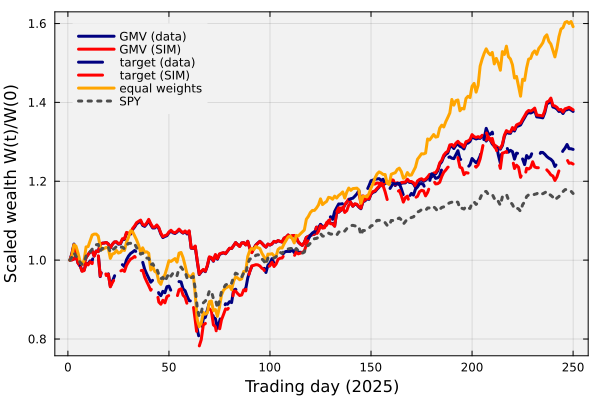

In [20]:
let
    # Plot scaled wealth W_t/W₀ against the trading-day index -
    p = plot(); # start an empty figure
    for (name, c, ls) ∈ [ # (name, color, line style) for each path
        ("GMV (data)", :navy, :solid),
        ("GMV (SIM)", :red, :solid),
        ("target (data)", :navy, :dash),
        ("target (SIM)", :red, :dash),
        ("equal weights", :orange, :solid),
        ("SPY", :gray30, :dot)
    ]
        # Undiscounted wealth per dollar invested, so every path starts at one.
        plot!(wealth_2025[name] ./ W₀, lw = 3, c = c, ls = ls, label = name)
    end

    # Style the plot -
    plot!(xlabel = "Trading day (2025)", ylabel = "Scaled wealth W(t)/W(0)",
        bg = "gray95", background_color_outside = "white", framestyle = :box,
        fg_legend = :transparent, legend = :topleft)
end

### Compare realized growth and risk
The table reports, for each wealth path:

- **Final wealth ratio:** $W_T/W_0$.
- **Realized mean growth:** $\ln(W_T/W_0)/T$, in inverse years.
- **Growth-rate standard deviation:** the sample standard deviation of the daily rates $\ln(W_{t_k}/W_{t_{k-1}})/\Delta t$, also in inverse years.

Here, $t_k$ is the time of trading day $k$, and $T$ is the number of observed trading intervals multiplied by $\Delta t$. We compute daily log changes with [the `diff(...)` function](https://docs.julialang.org/en/v1/base/arrays/#Base.diff):

In [21]:
let
    # Initialize an empty results table -
    df = DataFrame(
        portfolio = String[],
        W_T_over_W_0 = Float64[],
        growth_2025 = Float64[],
        σ_g_2025 = Float64[]
    );

    # Measure realized growth and risk from each buy-and-hold wealth path -
    for name ∈ ["GMV (data)", "GMV (SIM)", "target (data)", "target (SIM)", "equal weights", "SPY"]
        W = wealth_2025[name]; # wealth path (USD), one entry per trading day
        T = (length(W) - 1)*Δt; # number of trading intervals times Δt (yr)
        # log. takes the log of each entry, and diff subtracts each entry from the next.
        g_daily = diff(log.(W)) ./ Δt; # ln(W_{t_k}/W_{t_{k-1}})/Δt for each interval (1/yr)
        # The mean of g_daily telescopes to ln(W_T/W_0)/T, the growth_2025 column.
        push!(df, (
            portfolio = name,
            W_T_over_W_0 = round(W[end]/W[1], digits=4), # W[end] is the last entry, W_T
            growth_2025 = round(log(W[end]/W[1])/T, digits=4), # realized mean growth (1/yr)
            σ_g_2025 = round(std(g_daily), digits=3) # sample std with the N-1 divisor (1/yr)
        ));
    end

    # Display the table -
    pretty_table(df, backend = :text,
        table_format = TextTableFormat(borders = text_table_borders__compact))
end

 --------------- -------------- ------------- ----------
      portfolio   W_T_over_W_0   growth_2025   σ_g_2025 
         String        Float64       Float64    Float64 
 --------------- -------------- ------------- ----------
     GMV (data)          1.377        0.3238      1.996
      GMV (SIM)         1.3812        0.3268      2.019
  target (data)         1.2808        0.2505      3.215
   target (SIM)         1.2437        0.2207      3.408
  equal weights         1.5921        0.4706      3.487
            SPY         1.1691        0.1581      2.206
 --------------- -------------- ------------- ----------


__What do we see?__ For the default firms, each data portfolio and its SIM partner end 2025 within a few percent of each other. The data portfolio has the lower realized risk in both pairs. Your results may differ if you change the tickers.

__So does the covariance model change the portfolio we choose?__ Yes, mainly through the residual covariances the SIM drops. Those shift the weights, and under the sample covariance the SIM weights never carry less risk than the data frontier. For the default firms, the extra risk was small, and one year cannot rank portfolios this close.

The optional [estimation-risk notebook](advanced/estimation-risk/CHEME-5660-L7a-Advanced-EstimationRisk-Fall-2026.ipynb) measures how much the weights move when the inputs change.

___

## Summary
In this example, we assembled the minimum-variance inputs for the same firms from the training data and from the SIM archive, and found where their covariances differ. We then traced both long-only frontiers, compared the weights, and scored the portfolios on 2025 data.

> __Key Takeaways:__
>
> * **The SIM changes only the covariance:** A least-squares line with an intercept passes through the sample means, so the SIM and sample mean vectors agree on the same training days. The two covariances differ by the off-diagonal residual covariances and a negligible degrees-of-freedom factor on the diagonal.
> * **The covariance error has a sign structure:** On balance, positive residual correlations among the firms a portfolio holds make the SIM understate its risk, and negative ones make it overstate. Under the sample covariance, the SIM weights carry at least the data frontier's risk at every growth floor.
> * **One test year cannot rank the input sets:** For the displayed selection, each data portfolio and its SIM partner ended 2025 within a few percent of each other in wealth. The SIM's fewer parameters cost little for these firms, but one year of prices is too little to rank the two input sets.

The [tangent portfolio example](CHEME-5660-L7a-Example-SIM-MinVar-RRFA-Fall-2026.ipynb) adds a risk-free asset to the SIM inputs, finds the tangent portfolio and the capital allocation line, and tests portfolios that lend or borrow.

___

## Disclaimer and Risks
__This content is offered solely for training and informational purposes__. No offer or solicitation to buy or sell securities or derivative products or any investment or trading advice or strategy is made, given, or endorsed by the teaching team. 

__Trading involves risk__. Carefully review your financial situation before investing in securities, futures contracts, options, or commodity interests. Past performance, whether actual or indicated by historical tests of strategies, is no guarantee of future performance or success. Trading is generally inappropriate for someone with limited resources, investment or trading experience, or a low-risk tolerance. Only risk capital that is not required for living expenses should be used.

__You are fully responsible for any investment or trading decisions you make__. Such decisions should be based solely on evaluating your financial circumstances, investment or trading objectives, risk tolerance, and liquidity needs.

___